# Data Preprocessing Pipeline
**Mục tiêu**: Xử lý dữ liệu thô từ `data/raw/book_dataset.csv` → xuất ra `data/processed/`

Pipeline:
1. Load & khảo sát data thô
2. Xử lý Missing Values
3. Xử lý Outliers (IQR Capping + Log Transform)
4. Feature Engineering (derived features)
5. Category Mapping & One-Hot Encoding
6. So sánh & Voting Scaler
7. Export data cho ML training và EDA


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

print("Libraries loaded ✓")


Libraries loaded ✓


---
## 1. Load & Khảo sát Data thô


In [2]:
df = pd.read_csv("../../data/raw/book_dataset.csv", low_memory=False)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Shape: (132955, 26)
Columns: ['id', 'name', 'price', 'list_price', 'discount_rate', 'rating_average', 'review_count', 'all_time_quantity_sold', 'authors', 'publisher_vn', 'manufacturer', 'isbn13', 'book_cover', 'number_of_page', 'publication_date', 'current_seller_name', 'inventory_status', 'stock', 'has_freeship', 'is_authentic', 'has_return_policy', 'cat_level_1', 'cat_level_2', 'cat_level_3', 'cat_level_4', 'cat_level_5']


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132955 entries, 0 to 132954
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      132955 non-null  int64  
 1   name                    132955 non-null  object 
 2   price                   132955 non-null  int64  
 3   list_price              132955 non-null  int64  
 4   discount_rate           132955 non-null  int64  
 5   rating_average          132955 non-null  float64
 6   review_count            132955 non-null  int64  
 7   all_time_quantity_sold  132955 non-null  int64  
 8   authors                 86261 non-null   object 
 9   publisher_vn            132296 non-null  object 
 10  manufacturer            126583 non-null  object 
 11  isbn13                  14505 non-null   object 
 12  book_cover              86871 non-null   object 
 13  number_of_page          66089 non-null   object 
 14  publication_date    

In [4]:
df.describe()


,id,price,list_price,discount_rate,rating_average,review_count,all_time_quantity_sold,stock
count,1.329550e+05,1.329550e+05,1.329550e+05,132955.000000,132955.000000,132955.000000,132955.000000,132579.0
mean,2.140448e+08,1.803609e+05,1.932208e+05,6.726697,1.143218,6.110774,54.105720,1000.0
std,8.904153e+07,2.125998e+05,2.235136e+05,10.549624,2.060529,79.503230,678.679874,0.0
min,3.136070e+05,0.000000e+00,4.000000e+03,0.000000,0.000000,0.000000,0.000000,1000.0
25%,1.819931e+08,8.000000e+04,8.900000e+04,0.000000,0.000000,0.000000,0.000000,1000.0
50%,2.706603e+08,1.348000e+05,1.480000e+05,0.000000,0.000000,0.000000,1.000000,1000.0
75%,2.768091e+08,2.130000e+05,2.290000e+05,10.000000,0.000000,0.000000,6.000000,1000.0
max,2.793159e+08,9.990000e+06,1.003000e+07,100.000000,5.000000,7257.000000,75282.000000,1000.0


In [5]:
df.head(5)


,id,name,price,list_price,discount_rate,rating_average,review_count,all_time_quantity_sold,authors,publisher_vn,...,inventory_status,stock,has_freeship,is_authentic,has_return_policy,cat_level_1,cat_level_2,cat_level_3,cat_level_4,cat_level_5
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...",83930,109000,23,4.8,7257,75282,Tống Mặc,Skybooks,...,available,1000.0,False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-ky-nang-song,sach-ky-nang-song,NaN
1,52789367,Sách Nhà Giả Kim (Tái Bản),78000,95000,18,5.0,6076,39825,Paulo Coelho,Nhã Nam,...,available,1000.0,False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,tac-pham-kinh-dien,tac-pham-kinh-dien-nuoc-ngoai
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...",137830,179000,23,4.8,5492,27187,Cao Minh,Vibooks,...,available,1000.0,False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-nuoc-ngoai
3,278277832,Sách Vui Vẻ Không Quạu Nha - Tản Văn,60830,79000,23,4.7,5338,13,Ở Đây Zui Nè,Skybooks,...,available,1000.0,False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-viet-nam
4,71345381,Sách Thay Đổi Cuộc Sống Với Nhân Số Học - Lê Đ...,173462,248000,30,4.8,5294,31431,David A. Phillips,First News - Trí Việt,...,available,1000.0,False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-ky-nang-song,sach-ky-nang-song,NaN


---
## 2. Xử lý Missing Values


### 2.1 Kiểm tra missing


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'count': missing,
    'percent': missing_pct
})
missing_df = missing_df[missing_df['count'] > 0].sort_values('count', ascending=False)
print("=== Các cột có Missing Values ===")
print(missing_df)
print(f"\nTổng giá trị missing: {df.isnull().sum().sum()}")


=== Các cột có Missing Values ===
                      count  percent
isbn13               118450    89.09
cat_level_5           85931    64.63
publication_date      77844    58.55
number_of_page        66866    50.29
authors               46694    35.12
book_cover            46084    34.66
manufacturer           6372     4.79
cat_level_4            2051     1.54
publisher_vn            659     0.50
stock                   376     0.28
current_seller_name     376     0.28

Tổng giá trị missing: 451703


### 2.2 Chiến lược xử lý Missing

| Cột | Chiến lược | Lý do |
|-----|-----------|-------|
| `rating_average` | Fill **median** | Phân phối lệch, median robust hơn mean |
| `review_count` | Fill **0** | Chưa có review = 0 review |
| `discount_rate` | Fill **0** | Không có thông tin = không giảm giá |
| `number_of_page` | Parse numeric + fill **median** | Có giá trị text lẫn, median robust |
| `cat_level_2` | Fill **"Unknown"** | Categorical, không nên drop |
| `publisher_vn` | Fill **"Unknown"** | Categorical, không nên drop |
| `authors` | Fill **"Unknown"** | Categorical |
| `isbn13` | **Không xử lý** | Không dùng cho ML |


In [7]:
# Rating
print(f"rating_average - median: {df['rating_average'].median()}")
df['rating_average'] = df['rating_average'].fillna(df['rating_average'].median())

# Review count
df['review_count'] = df['review_count'].fillna(0)

# Discount rate
df['discount_rate'] = df['discount_rate'].fillna(0)

# Number of page (có thể chứa text)
df['number_of_page'] = pd.to_numeric(df['number_of_page'], errors='coerce')
page_median = df['number_of_page'].median()
print(f"number_of_page - median: {page_median}")
df['number_of_page'] = df['number_of_page'].fillna(page_median)

# Categorical
df['cat_level_2'] = df['cat_level_2'].fillna("Unknown")
df['publisher_vn'] = df['publisher_vn'].fillna("Unknown")
df['authors'] = df['authors'].fillna("Unknown")

print("\n✓ Missing values đã xử lý xong")


rating_average - median: 0.0
number_of_page - median: 263.0

✓ Missing values đã xử lý xong


### 2.3 Kiểm tra lại sau khi xử lý


In [8]:
check_cols = ['rating_average', 'review_count', 'discount_rate', 'number_of_page', 'cat_level_2', 'publisher_vn']
print("Missing sau xử lý:")
for col in check_cols:
    print(f"  {col}: {df[col].isnull().sum()}")


Missing sau xử lý:
  rating_average: 0
  review_count: 0
  discount_rate: 0
  number_of_page: 0
  cat_level_2: 0
  publisher_vn: 0


---
## 3. Xử lý Outliers


### 3.1 Khảo sát phân phối trước xử lý
Cần kiểm tra các cột số để xác định mức độ outlier.


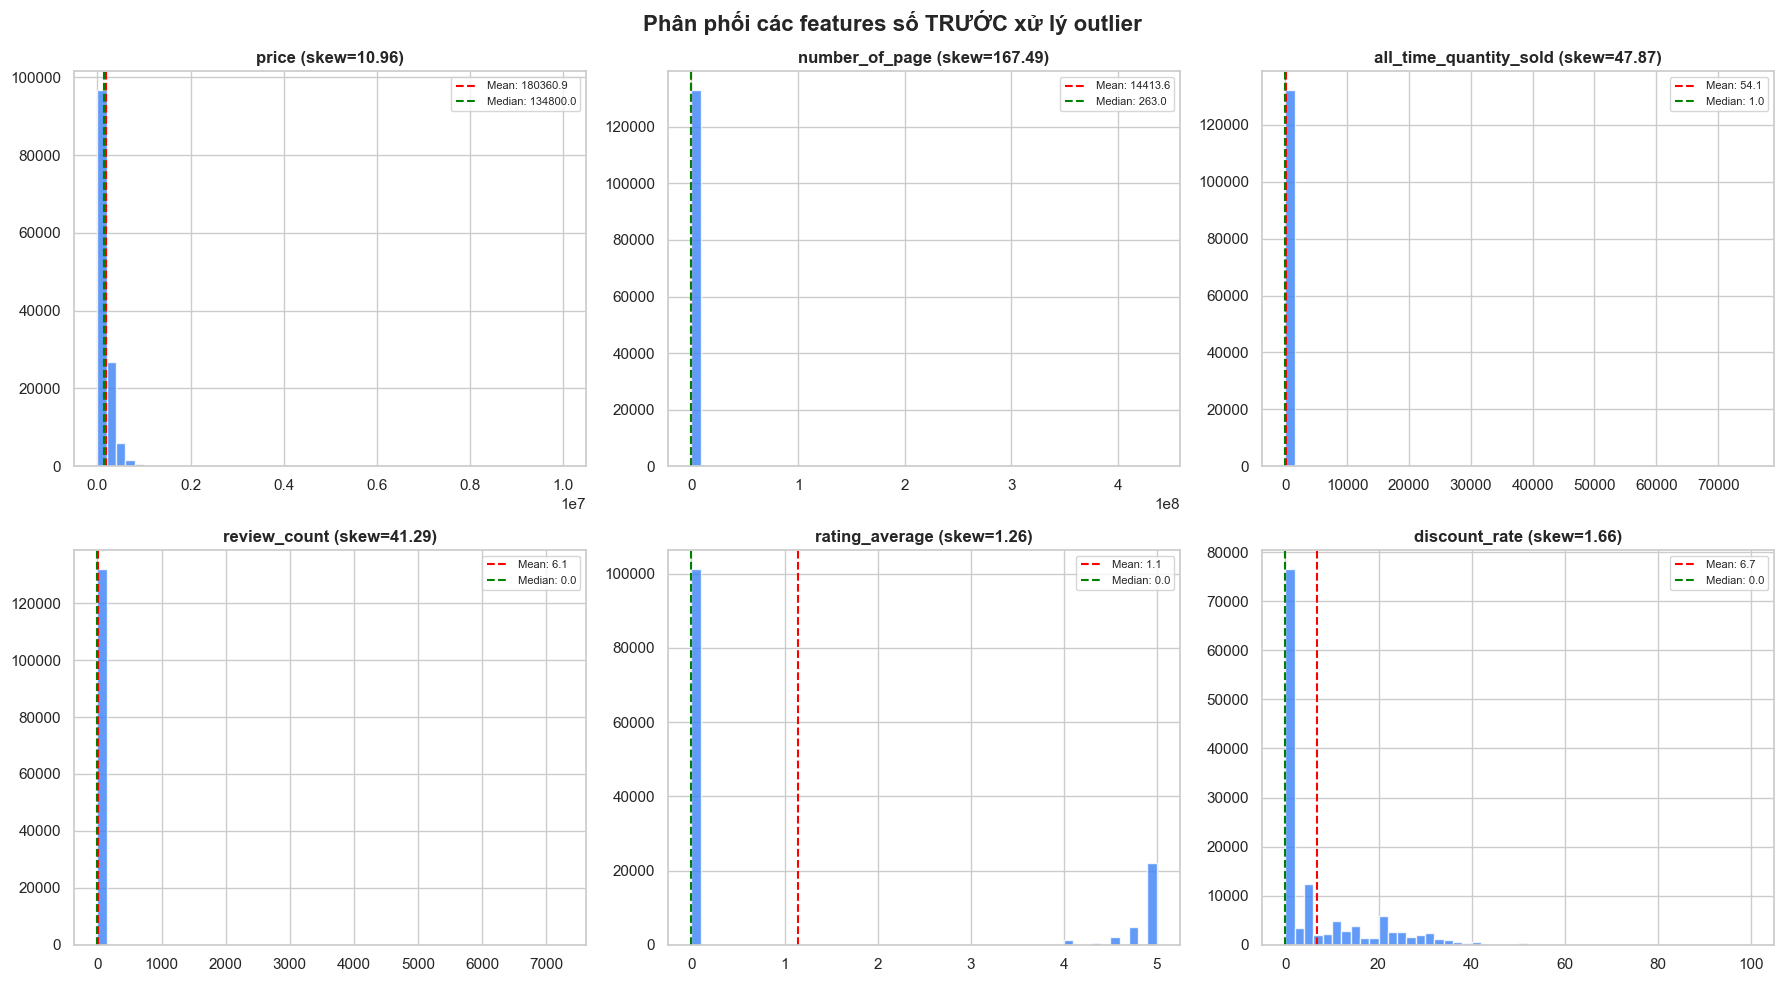

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cols_check = ['price', 'number_of_page', 'all_time_quantity_sold', 'review_count', 'rating_average', 'discount_rate']
for ax, col in zip(axes.flat, cols_check):
    data = df[col].dropna()
    ax.hist(data, bins=50, color='#3b82f6', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.1f}')
    ax.set_title(f'{col} (skew={data.skew():.2f})', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Phân phối các features số TRƯỚC xử lý outlier', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.2 Boxplot kiểm tra outlier

Sử dụng boxplot để trực quan hóa phân phối dữ liệu của các biến số (`price`, `number_of_page`, `all_time_quantity_sold`, `review_count`).  
Thông qua biểu đồ này, có thể dễ dàng phát hiện các giá trị ngoại lai (outliers) dựa trên các điểm nằm ngoài khoảng whiskers.


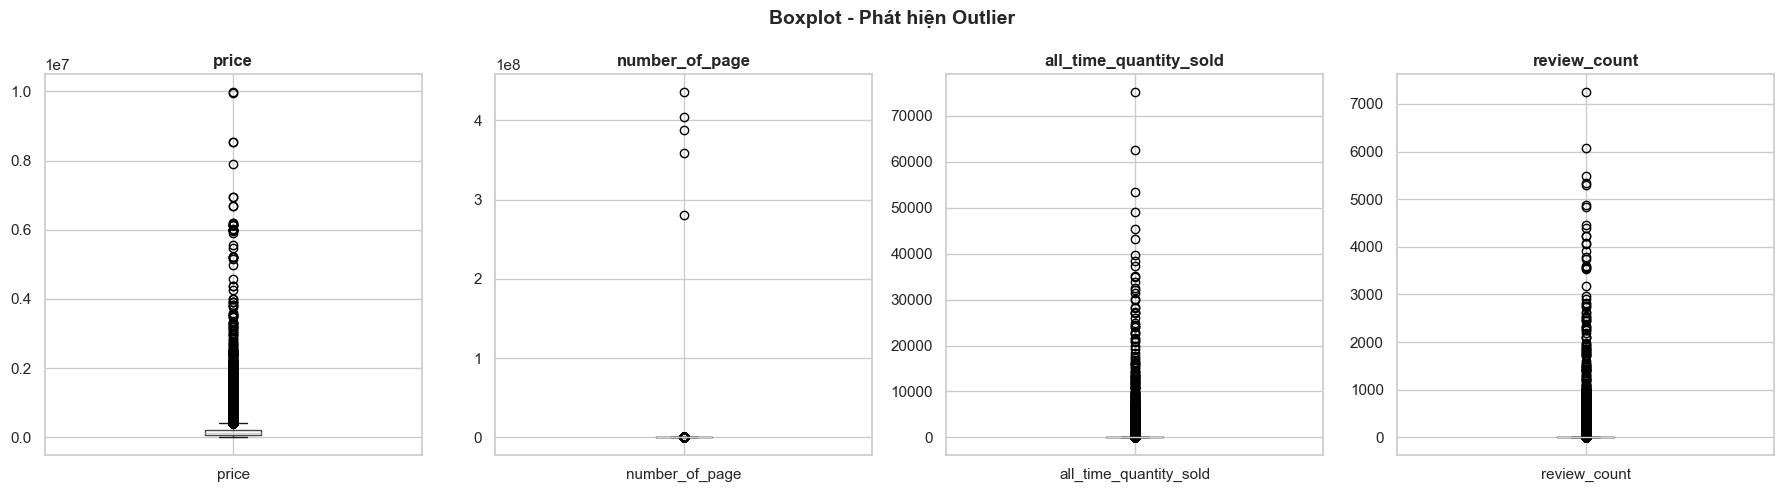

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, ['price', 'number_of_page', 'all_time_quantity_sold', 'review_count']):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col, fontweight='bold')
plt.suptitle('Boxplot - Phát hiện Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Nhận xét

- Cả 4 biến đều xuất hiện rất nhiều outlier, thể hiện qua các điểm nằm ngoài whiskers.
- Phân phối dữ liệu bị lệch phải (right-skewed), đặc biệt rõ ở `price`, `all_time_quantity_sold` và `review_count`.
- `number_of_page` cũng có outlier nhưng ít hơn, tuy nhiên vẫn tồn tại các giá trị bất thường rất lớn.
- Sự chênh lệch lớn giữa median và các giá trị cực đại cho thấy dữ liệu không đồng đều, có thể ảnh hưởng đến mô hình nếu không xử lý.

### 3.3 Xử lý Outlier

**Chiến lược:**
- `price`, `number_of_page`: **IQR Capping (Winsorization)** — giới hạn các giá trị vượt ngoài khoảng `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` nhằm giảm ảnh hưởng của outlier nhưng vẫn giữ lại dữ liệu.
- `all_time_quantity_sold`, `review_count`: **Log Transform** — do phân phối lệch phải rất mạnh, sử dụng log để giảm skewness và ổn định phương sai.

**Giải thích lựa chọn:**
- Các biến như `price` và `number_of_page` có outlier mang tính nhiễu → phù hợp để **capping**.
- Ngược lại, `sales` và `review` thường tuân theo phân phối **power-law** (ít sản phẩm bán cực nhiều) → nếu capping sẽ làm mất thông tin quan trọng, nên dùng **log transform**.

**Kết quả:**
- IQR capping giúp giảm ảnh hưởng của các giá trị cực đoan.
- Log transform làm giảm độ lệch (skewness), đưa phân phối về gần chuẩn hơn → cải thiện hiệu quả cho các mô hình tuyến tính.

In [11]:
def cap_outliers_iqr(dataframe, column):
    """Cap outliers dùng IQR 1.5x (Winsorization)"""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    before_count = ((dataframe[column] < lower) | (dataframe[column] > upper)).sum()
    dataframe[column] = np.clip(dataframe[column], lower, upper)
    print(f"  {column}: capped {before_count} outliers | bounds=[{lower:.0f}, {upper:.0f}]")
    return dataframe

print("=== IQR Capping ===")
df = cap_outliers_iqr(df, 'price')
df = cap_outliers_iqr(df, 'number_of_page')


=== IQR Capping ===
  price: capped 8315 outliers | bounds=[-119500, 412500]
  number_of_page: capped 66021 outliers | bounds=[263, 263]


In [12]:
# Log Transform cho target và review
df['log_sales'] = np.log1p(df['all_time_quantity_sold'].fillna(0))
df['log_review_count'] = np.log1p(df['review_count'])

print("=== Log Transform ===")
print(f"  all_time_quantity_sold: skew {df['all_time_quantity_sold'].skew():.2f} → log_sales skew {df['log_sales'].skew():.2f}")
print(f"  review_count: skew {df['review_count'].skew():.2f} → log_review_count skew {df['log_review_count'].skew():.2f}")


=== Log Transform ===
  all_time_quantity_sold: skew 47.87 → log_sales skew 1.56
  review_count: skew 41.29 → log_review_count skew 3.04


### 3.4 Kiểm tra phân phối SAU xử lý


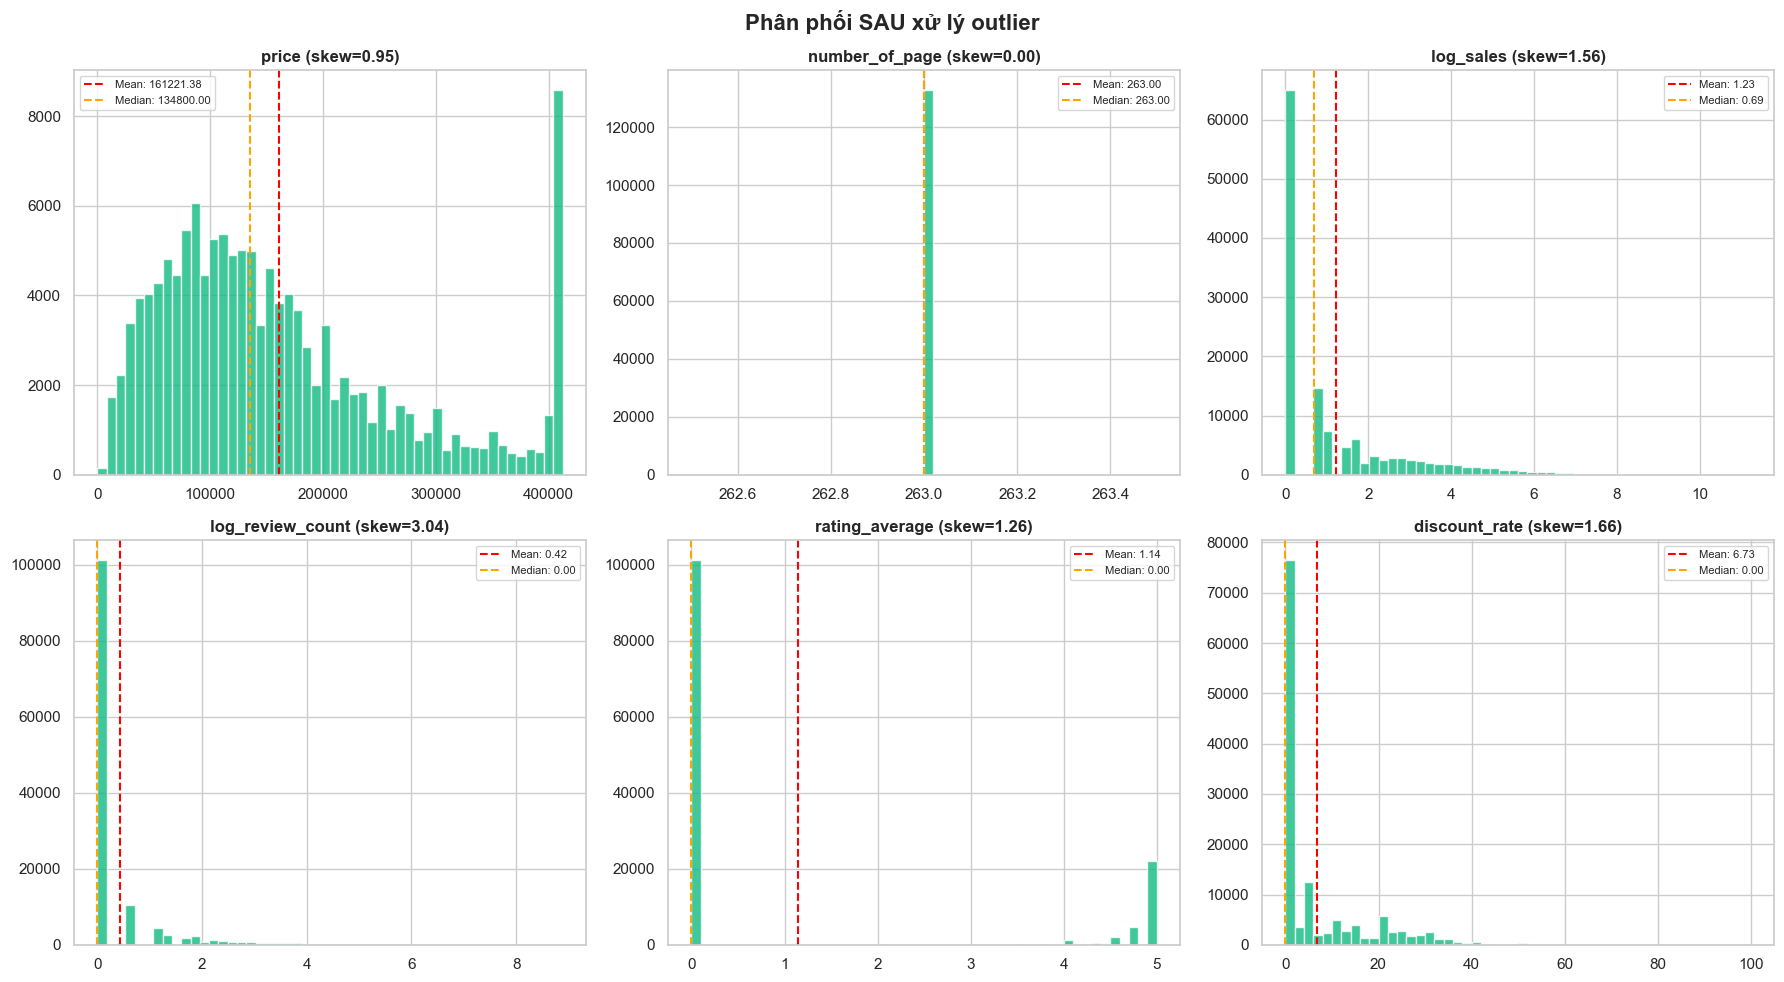

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
after_cols = ['price', 'number_of_page', 'log_sales', 'log_review_count', 'rating_average', 'discount_rate']
for ax, col in zip(axes.flat, after_cols):
    data = df[col].dropna()
    ax.hist(data, bins=50, color='#10b981', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='--', label=f'Median: {data.median():.2f}')
    ax.set_title(f'{col} (skew={data.skew():.2f})', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Phân phối SAU xử lý outlier', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. Feature Engineering


### 4.1 Chuẩn hóa Discount Rate

Discount rate trong dữ liệu có thể tồn tại ở hai dạng:
- Dạng phần trăm: 23, 18, ...
- Dạng thập phân: 0.23, 0.18, ...

Do đó, cần chuẩn hóa về cùng một thang đo [0, 1] để đảm bảo tính nhất quán.

**Cách xử lý:**
- Nếu giá trị lớn hơn 1 → coi là dạng %, chia cho 100
- Ngược lại → giữ nguyên

**Kết quả:**
- Biến `discount_rate_norm` được đưa về đúng khoảng [0, 1]
- Tránh sai lệch khi đưa vào mô hình hoặc so sánh với các feature khác

In [14]:
if df['discount_rate'].max() > 1:
    df['discount_rate_norm'] = df['discount_rate'] / 100.0
    print(f"Discount rate dạng %: max={df['discount_rate'].max()}, đã chia 100")
else:
    df['discount_rate_norm'] = df['discount_rate']
    print(f"Discount rate đã ở dạng 0-1: max={df['discount_rate'].max()}")

print(f"discount_rate_norm range: [{df['discount_rate_norm'].min():.2f}, {df['discount_rate_norm'].max():.2f}]")


Discount rate dạng %: max=100, đã chia 100
discount_rate_norm range: [0.00, 1.00]


### 4.2 Derived Features

Tạo thêm các đặc trưng mới nhằm bổ sung thông tin và giúp mô hình học tốt hơn:

**Các feature được tạo:**
- `price_after_discount`: Giá sau khi áp dụng giảm giá → phản ánh giá thực tế người dùng trả.
- `is_high_rating`: Biến nhị phân (0/1), đánh dấu sách có rating cao (`> 4.5`).
- `is_heavy_book`: Biến nhị phân (0/1), đánh dấu sách có số trang lớn (`> 300`).

**Ý nghĩa:**
- Các feature mới giúp mô hình nắm bắt tốt hơn hành vi người dùng (ví dụ: ưu tiên sách giá rẻ hơn, rating cao, hoặc sách dày).
- Biến nhị phân giúp đơn giản hóa thông tin và phù hợp với các mô hình tuyến tính.

In [15]:
# Giá sau giảm giá
df['price_after_discount'] = df['price'] * (1 - df['discount_rate_norm'])

# Binary features
df['is_high_rating'] = (df['rating_average'] > 4.5).astype(int)
df['is_heavy_book'] = (df['number_of_page'] > 300).astype(int)

print("Derived features:")
print(f"  price_after_discount: mean={df['price_after_discount'].mean():.0f}")
print(f"  is_high_rating: {df['is_high_rating'].sum()} / {len(df)} ({df['is_high_rating'].mean()*100:.1f}%)")
print(f"  is_heavy_book: {df['is_heavy_book'].sum()} / {len(df)} ({df['is_heavy_book'].mean()*100:.1f}%)")


Derived features:
  price_after_discount: mean=152029
  is_high_rating: 27473 / 132955 (20.7%)
  is_heavy_book: 0 / 132955 (0.0%)


---
## 5. Category Mapping & One-Hot Encoding


### 5.1 Phân tích phân bố category


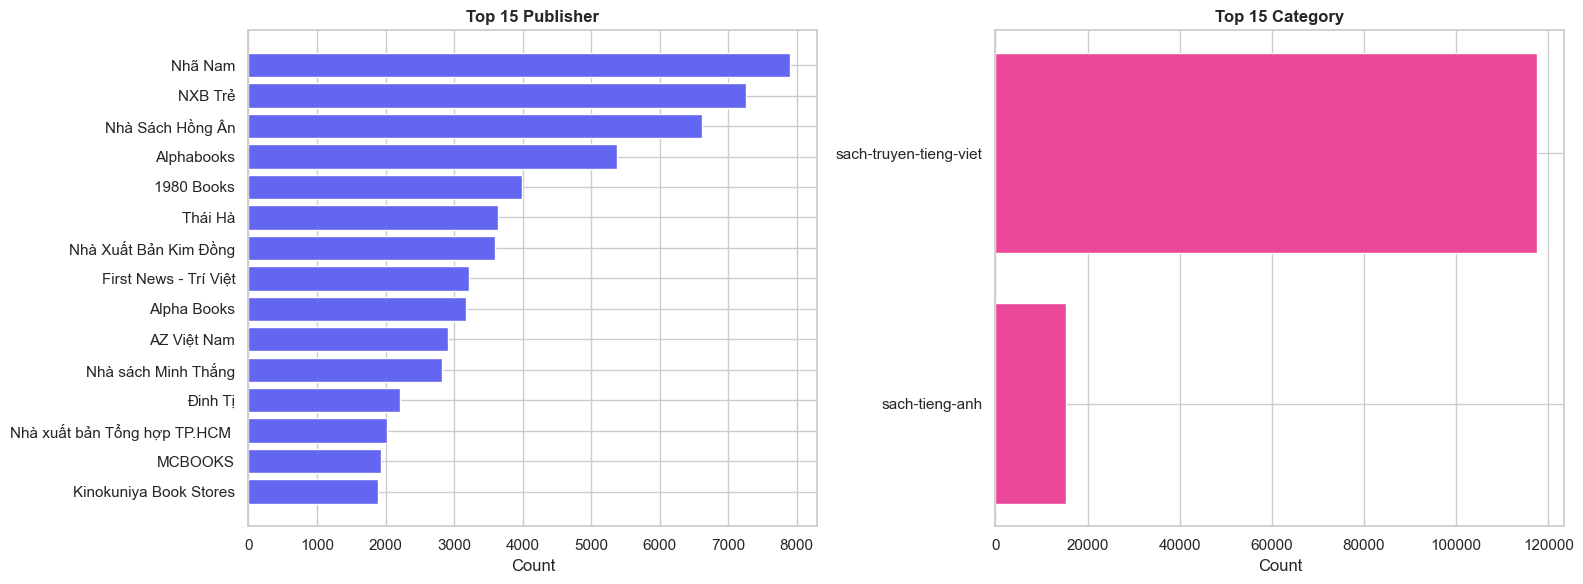

Unique publishers: 1322
Unique categories: 2


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Publisher distribution
pub_counts = df['publisher_vn'].value_counts()
axes[0].barh(pub_counts.head(15).index[::-1], pub_counts.head(15).values[::-1], color='#6366f1')
axes[0].set_title('Top 15 Publisher', fontweight='bold')
axes[0].set_xlabel('Count')

# Category distribution
cat_counts = df['cat_level_2'].value_counts()
axes[1].barh(cat_counts.head(15).index[::-1], cat_counts.head(15).values[::-1], color='#ec4899')
axes[1].set_title('Top 15 Category', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print(f"Unique publishers: {df['publisher_vn'].nunique()}")
print(f"Unique categories: {df['cat_level_2'].nunique()}")


### 5.2 Map: Top 10 + "Other"

Các biến phân loại như `publisher_vn` và `cat_level_2` có số lượng giá trị duy nhất (cardinality) rất lớn.  
Nếu áp dụng One-Hot Encoding trực tiếp sẽ tạo ra quá nhiều cột → dễ gây **overfitting** và tăng chi phí tính toán.

**Chiến lược:**
- Giữ lại **Top 10** giá trị xuất hiện nhiều nhất
- Gộp tất cả các giá trị còn lại vào nhóm `"Other"`

**Lợi ích:**
- Giảm số chiều dữ liệu sau khi encode
- Hạn chế overfitting do các category hiếm
- Giữ được thông tin quan trọng từ các nhóm phổ biến nhất

**Áp dụng cho:**
- `publisher_vn`
- `cat_level_2`

In [17]:
top_publishers = df['publisher_vn'].value_counts().nlargest(10).index.tolist()
top_cats = df['cat_level_2'].value_counts().nlargest(10).index.tolist()

print("Top 10 Publishers:")
for i, p in enumerate(top_publishers, 1):
    count = (df['publisher_vn'] == p).sum()
    print(f"  {i}. {p} ({count})")

print(f"\nTop 10 Categories:")
for i, c in enumerate(top_cats, 1):
    count = (df['cat_level_2'] == c).sum()
    print(f"  {i}. {c} ({count})")


Top 10 Publishers:
  1. Nhã Nam (7906)
  2. NXB Trẻ (7264)
  3. Nhà Sách Hồng Ân (6624)
  4. Alphabooks (5377)
  5. 1980 Books (3989)
  6. Thái Hà (3637)
  7. Nhà Xuất Bản Kim Đồng (3598)
  8. First News - Trí Việt (3214)
  9. Alpha Books (3173)
  10. AZ Việt Nam (2911)

Top 10 Categories:
  1. sach-truyen-tieng-viet (117567)
  2. sach-tieng-anh (15388)


In [18]:
df['publisher_vn_mapped'] = df['publisher_vn'].apply(lambda x: x if x in top_publishers else 'Other')
df['cat_level_2_mapped'] = df['cat_level_2'].apply(lambda x: x if x in top_cats else 'Other')

print("After mapping:")
print(f"  publisher_vn_mapped unique: {df['publisher_vn_mapped'].nunique()}")
print(f"  cat_level_2_mapped unique: {df['cat_level_2_mapped'].nunique()}")


After mapping:
  publisher_vn_mapped unique: 11
  cat_level_2_mapped unique: 2


### 5.3 One-Hot Encoding


In [19]:
df_encoded = pd.get_dummies(df, columns=['publisher_vn_mapped', 'cat_level_2_mapped'])

ohe_cols = [c for c in df_encoded.columns if c.startswith('publisher_vn_mapped_') or c.startswith('cat_level_2_mapped_')]
print(f"OHE columns created: {len(ohe_cols)}")
for col in ohe_cols:
    print(f"  {col}: {df_encoded[col].sum()} rows = 1")

print(f"\nDataFrame shape after OHE: {df_encoded.shape}")


OHE columns created: 13
  publisher_vn_mapped_1980 Books: 3989 rows = 1
  publisher_vn_mapped_AZ Việt Nam: 2911 rows = 1
  publisher_vn_mapped_Alpha Books: 3173 rows = 1
  publisher_vn_mapped_Alphabooks: 5377 rows = 1
  publisher_vn_mapped_First News - Trí Việt: 3214 rows = 1
  publisher_vn_mapped_NXB Trẻ: 7264 rows = 1
  publisher_vn_mapped_Nhà Sách Hồng Ân: 6624 rows = 1
  publisher_vn_mapped_Nhà Xuất Bản Kim Đồng: 3598 rows = 1
  publisher_vn_mapped_Nhã Nam: 7906 rows = 1
  publisher_vn_mapped_Other: 85262 rows = 1
  publisher_vn_mapped_Thái Hà: 3637 rows = 1
  cat_level_2_mapped_sach-tieng-anh: 15388 rows = 1
  cat_level_2_mapped_sach-truyen-tieng-viet: 117567 rows = 1

DataFrame shape after OHE: (132955, 45)


---
## 6. Voting Scaler


### 6.1 So sánh 3 Scalers
So sánh **StandardScaler**, **MinMaxScaler**, **RobustScaler** trên các features số.

| Scaler | Ưu điểm | Nhược điểm |
|--------|---------|------------|
| StandardScaler | Chuẩn hóa mean=0, std=1 | Nhạy outlier |
| MinMaxScaler | Scale về [0,1] | Bị kéo bởi extreme |
| RobustScaler | Dùng median+IQR | Chống outlier tốt |



StandardScaler:
  Mean range: [-0.000, 0.000]
  Std range:  [0.000, 1.000]

MinMaxScaler:
  Mean range: [0.000, 0.391]
  Std range:  [0.000, 0.412]

RobustScaler:
  Mean range: [0.000, 1.143]
  Std range:  [0.000, 2.061]


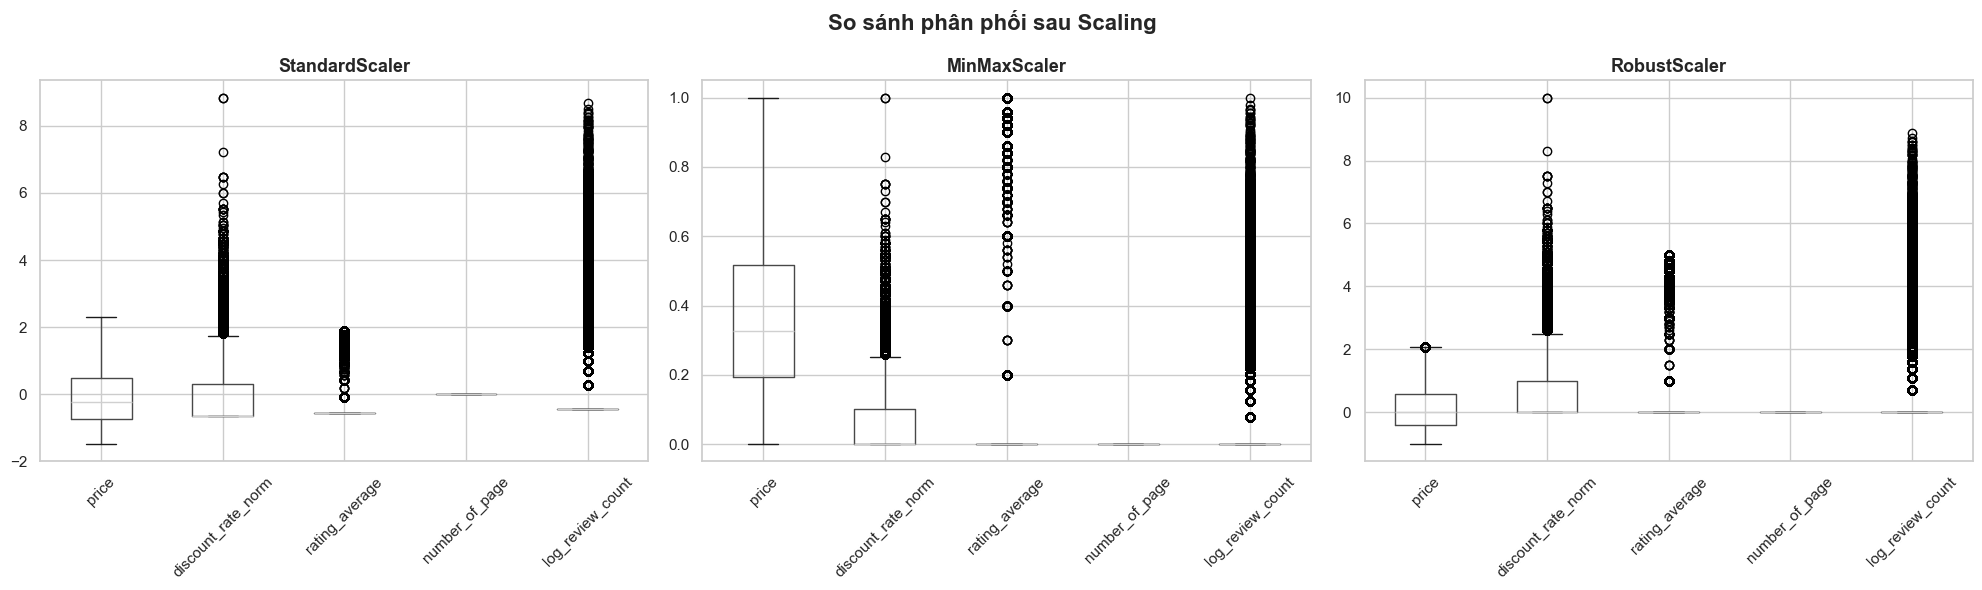

In [20]:
num_cols = ['price', 'discount_rate_norm', 'rating_average', 'number_of_page', 'log_review_count']
X_num = df_encoded[num_cols].copy()

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, scaler) in zip(axes, scalers.items()):
    X_scaled = pd.DataFrame(scaler.fit_transform(X_num), columns=num_cols)
    X_scaled.boxplot(ax=ax, vert=True)
    ax.set_title(name, fontweight='bold', fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    
    # In thống kê
    print(f"\n{name}:")
    print(f"  Mean range: [{X_scaled.mean().min():.3f}, {X_scaled.mean().max():.3f}]")
    print(f"  Std range:  [{X_scaled.std().min():.3f}, {X_scaled.std().max():.3f}]")

plt.suptitle('So sánh phân phối sau Scaling', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.2 Kết quả Voting

**=> Chọn RobustScaler** vì:
1. Data thương mại điện tử có rất nhiều outlier tự nhiên (sách best-seller vs sách bình thường)
2. RobustScaler dùng **median** và **IQR** thay vì mean/std → không bị kéo bởi extreme values
3. Sau khi đã IQR Capping ở bước 3, RobustScaler sẽ cho phân phối đều và ổn định nhất


In [21]:
chosen_scaler = RobustScaler()
df_encoded[num_cols] = chosen_scaler.fit_transform(df_encoded[num_cols])

print("✓ Applied RobustScaler")
print(f"\nSau khi scale:")
for col in num_cols:
    print(f"  {col}: mean={df_encoded[col].mean():.3f}, std={df_encoded[col].std():.3f}")


✓ Applied RobustScaler

Sau khi scale:
  price: mean=0.199, std=0.816
  discount_rate_norm: mean=0.673, std=1.055
  rating_average: mean=1.143, std=2.061
  number_of_page: mean=0.000, std=0.000
  log_review_count: mean=0.422, std=0.975


---
## 7. Export to `data/processed/`


### 7.1 Chuẩn bị data ML
Chỉ giữ các features cần thiết cho model + target `log_sales`.


In [22]:
ml_features = num_cols + ['is_high_rating', 'is_heavy_book'] + ohe_cols

df_ml = df_encoded[ml_features].copy()
df_ml['log_sales'] = df_encoded['log_sales']

print(f"ML Data shape: {df_ml.shape}")
print(f"Features: {len(ml_features)}")
print(f"Target: log_sales")
print(f"\nFeature list:")
for i, f in enumerate(ml_features, 1):
    print(f"  {i:2d}. {f}")


ML Data shape: (132955, 21)
Features: 20
Target: log_sales

Feature list:
   1. price
   2. discount_rate_norm
   3. rating_average
   4. number_of_page
   5. log_review_count
   6. is_high_rating
   7. is_heavy_book
   8. publisher_vn_mapped_1980 Books
   9. publisher_vn_mapped_AZ Việt Nam
  10. publisher_vn_mapped_Alpha Books
  11. publisher_vn_mapped_Alphabooks
  12. publisher_vn_mapped_First News - Trí Việt
  13. publisher_vn_mapped_NXB Trẻ
  14. publisher_vn_mapped_Nhà Sách Hồng Ân
  15. publisher_vn_mapped_Nhà Xuất Bản Kim Đồng
  16. publisher_vn_mapped_Nhã Nam
  17. publisher_vn_mapped_Other
  18. publisher_vn_mapped_Thái Hà
  19. cat_level_2_mapped_sach-tieng-anh
  20. cat_level_2_mapped_sach-truyen-tieng-viet


### 7.2 Chuẩn bị data EDA
Data EDA giữ nguyên giá trị thật (chưa scale) + thêm các cột bucket hóa cho dashboard.


In [23]:
# Reload raw và chỉ fill missing (không scale, không OHE)
df_eda = pd.read_csv("../../data/raw/book_dataset.csv", low_memory=False)

# Fill missing
df_eda['rating_average'] = df_eda['rating_average'].fillna(df_eda['rating_average'].median())
df_eda['review_count'] = df_eda['review_count'].fillna(0)
df_eda['discount_rate'] = df_eda['discount_rate'].fillna(0)
df_eda['number_of_page'] = pd.to_numeric(df_eda['number_of_page'], errors='coerce')
df_eda['number_of_page'] = df_eda['number_of_page'].fillna(df_eda['number_of_page'].median())
df_eda['cat_level_2'] = df_eda['cat_level_2'].fillna("Unknown")
df_eda['publisher_vn'] = df_eda['publisher_vn'].fillna("Unknown")

# Normalize discount
if df_eda['discount_rate'].max() > 1:
    df_eda['discount_rate_norm'] = df_eda['discount_rate'] / 100.0
else:
    df_eda['discount_rate_norm'] = df_eda['discount_rate']

# Log sales
df_eda['log_sales'] = np.log1p(df_eda['all_time_quantity_sold'].fillna(0))

# Bucket hóa
df_eda['price_bucket'] = pd.cut(
    df_eda['price'] / 1000,
    bins=[0, 50, 100, 200, 500, 1000, np.inf],
    labels=['0-50k', '50-100k', '100-200k', '200-500k', '500-1m', '>1m']
)
df_eda['page_bucket'] = pd.cut(
    df_eda['number_of_page'],
    bins=[0, 100, 300, 500, 1000, np.inf],
    labels=['0-100', '100-300', '300-500', '500-1000', '>1000']
)
df_eda['discount_bucket'] = pd.cut(
    df_eda['discount_rate_norm'],
    bins=[-0.01, 0.1, 0.3, 0.5, 0.7, 1.0],
    labels=['0-10%', '10-30%', '30-50%', '50-70%', '70-100%']
)

print(f"EDA Data shape: {df_eda.shape}")


EDA Data shape: (132955, 31)


### 7.3 Lưu file


In [24]:
os.makedirs("../../data/processed", exist_ok=True)

# Save ML data
df_ml.to_csv("../../data/processed/data_ml.csv", index=False)

# Save EDA data
df_eda.to_csv("../../data/processed/data_eda.csv", index=False)

# Save metadata
metadata = {
    'features': ml_features,
    'top_publishers': top_publishers,
    'top_cats': top_cats,
}
joblib.dump(metadata, "../../data/processed/ml_metadata.pkl")
joblib.dump(chosen_scaler, "../../data/processed/numerical_scaler.pkl")

print("=" * 50)
print("✅ EXPORT HOÀN TẤT!")
print("=" * 50)
print(f"\n📁 data/processed/")
print(f"  ├── data_ml.csv          ({df_ml.shape})")
print(f"  ├── data_eda.csv         ({df_eda.shape})")
print(f"  ├── ml_metadata.pkl")
print(f"  └── numerical_scaler.pkl")


✅ EXPORT HOÀN TẤT!

📁 data/processed/
  ├── data_ml.csv          ((132955, 21))
  ├── data_eda.csv         ((132955, 31))
  ├── ml_metadata.pkl
  └── numerical_scaler.pkl
